# Lab 4: Regression Analysis with Regularization Techniques

**Name:** [Your Name]
**Course:** MSCS-634 – Advanced Big Data and Data Mining
**Assignment:** Lab 4 – Regression Analysis with Regularization Techniques
**Date:** June 2026


## Overview

This notebook explores multiple regression techniques on the **Diabetes Dataset** from `sklearn.datasets`. We implement Simple Linear Regression, Multiple Regression, and Polynomial Regression, then apply Ridge and Lasso regularization to evaluate how these methods help control overfitting. Model performance is assessed using MAE, MSE, RMSE, and R², with visualizations to support interpretation.

## Step 1: Data Preparation

In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

%matplotlib inline

In [2]:
# Load the Diabetes dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


**About the dataset:** The Diabetes dataset contains 442 patient records with 10 baseline health measurements (age, sex, BMI, blood pressure, and six blood serum measurements) used to predict a quantitative measure of disease progression one year after baseline. All feature columns have already been mean-centered and scaled by sklearn.

In [3]:
# Explore feature names and basic statistics
print("Feature names:", diabetes.feature_names)
print("\nTarget variable summary:")
print(df['target'].describe())

df.describe()

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target variable summary:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


No missing values are present in the dataset, so no imputation or row removal is required. Because the sklearn-provided features are already standardized, no additional scaling is needed for this lab.

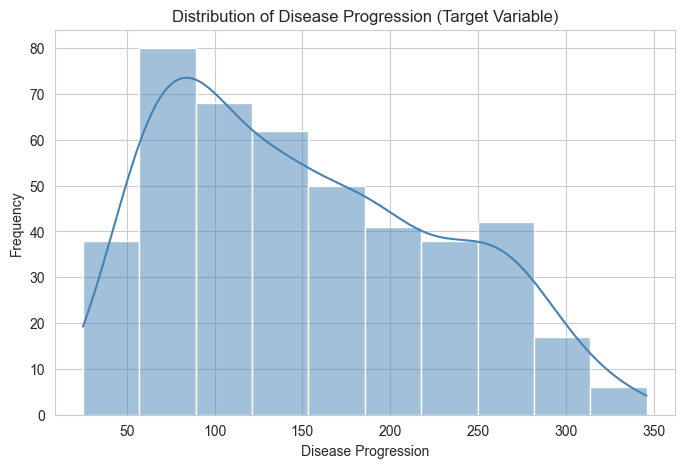

In [5]:
# Visualize the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df['target'], kde=True, color='steelblue')
plt.title('Distribution of Disease Progression (Target Variable)')
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.show()

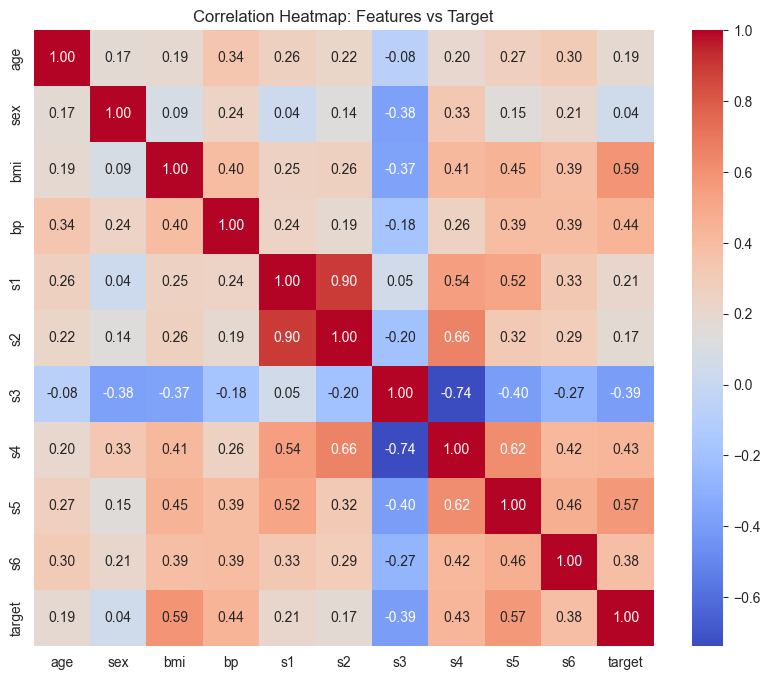

In [6]:
# Visualize correlations between features and the target
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Features vs Target')
plt.show()

From the heatmap, **BMI (`bmi`)** and **`s5`** (a blood serum measurement) show the strongest positive correlation with disease progression, making `bmi` a strong candidate for the simple linear regression model in the next step.

## Step 2: Simple Linear Regression

In [7]:
# Use BMI as the single independent variable (strongest correlation with target)
X_simple = df[['bmi']]
y = df['target']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train_s)

y_pred_s = lin_reg.predict(X_test_s)

mae_s = mean_absolute_error(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(f"Simple Linear Regression (feature: bmi)")
print(f"MAE:  {mae_s:.2f}")
print(f"MSE:  {mse_s:.2f}")
print(f"RMSE: {rmse_s:.2f}")
print(f"R^2:  {r2_s:.4f}")

Simple Linear Regression (feature: bmi)
MAE:  52.26
MSE:  4061.83
RMSE: 63.73
R^2:  0.2334


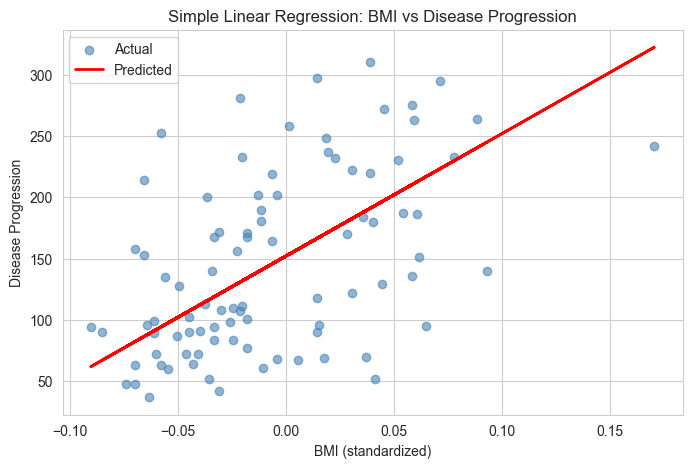

In [8]:
# Visualize predictions vs actual data
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, color='steelblue', alpha=0.6, label='Actual')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Predicted')
plt.title('Simple Linear Regression: BMI vs Disease Progression')
plt.xlabel('BMI (standardized)')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()

The simple linear regression model using only `bmi` captures a moderate linear relationship with disease progression, but the relatively low R² indicates that a single feature cannot fully explain the variance in the target, motivating the multiple regression approach in Step 3.

## Step 3: Multiple Regression

In [9]:
# Use all available features as independent variables
X_multi = df.drop(columns=['target'])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

multi_reg = LinearRegression()
multi_reg.fit(X_train_m, y_train_m)

y_pred_m = multi_reg.predict(X_test_m)

mae_m = mean_absolute_error(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

print("Multiple Regression (all 10 features)")
print(f"MAE:  {mae_m:.2f}")
print(f"MSE:  {mse_m:.2f}")
print(f"RMSE: {rmse_m:.2f}")
print(f"R^2:  {r2_m:.4f}")

Multiple Regression (all 10 features)
MAE:  42.79
MSE:  2900.19
RMSE: 53.85
R^2:  0.4526


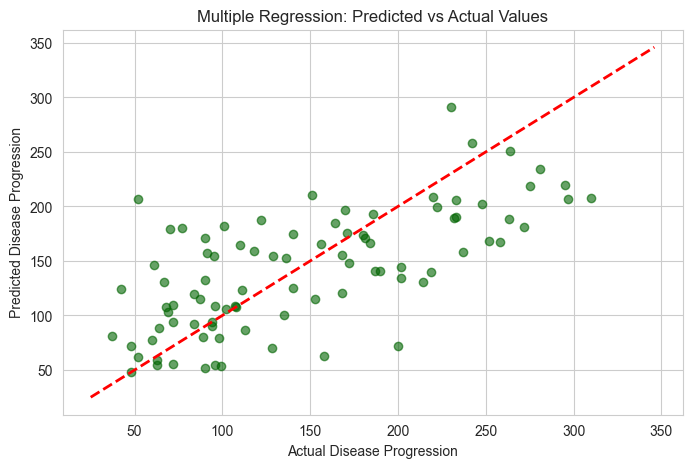

In [10]:
# Visualize predicted vs actual values
plt.figure(figsize=(8, 5))
plt.scatter(y_test_m, y_pred_m, color='darkgreen', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
plt.title('Multiple Regression: Predicted vs Actual Values')
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.show()

In [11]:
# Compare feature coefficients
coef_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_reg.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

coef_df

,Feature,Coefficient
4,s1,-931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,-241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021


Using all 10 features substantially improves R² compared to the single-feature model, confirming that disease progression is influenced by a combination of factors rather than BMI alone. The coefficient table shows `bmi` and `s5` as the strongest positive predictors, consistent with the correlation heatmap from Step 1.

## Step 4: Polynomial Regression

In [12]:
# Extend the multiple regression model with polynomial features at varying degrees
degrees = [1, 2, 3, 4]
poly_results = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_m)
    X_test_poly = poly.transform(X_test_m)

    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train_m)

    # Performance on training data (to detect overfitting)
    y_train_pred = poly_reg.predict(X_train_poly)
    train_r2 = r2_score(y_train_m, y_train_pred)

    # Performance on test data
    y_test_pred = poly_reg.predict(X_test_poly)
    test_mae = mean_absolute_error(y_test_m, y_test_pred)
    test_mse = mean_squared_error(y_test_m, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test_m, y_test_pred)

    poly_results.append({
        'Degree': degree,
        'Num_Features': X_train_poly.shape[1],
        'Train_R2': train_r2,
        'Test_MAE': test_mae,
        'Test_MSE': test_mse,
        'Test_RMSE': test_rmse,
        'Test_R2': test_r2
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Degree,Num_Features,Train_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,1,10,0.527919,42.794095,2900.193628,53.853446,0.452603
1,2,65,0.606158,43.581693,3096.028307,55.641965,0.415640
2,3,285,0.877293,164.853897,82446.048060,287.134199,-14.561285
3,4,1000,1.000000,261.667144,146907.593453,383.285264,-26.728083


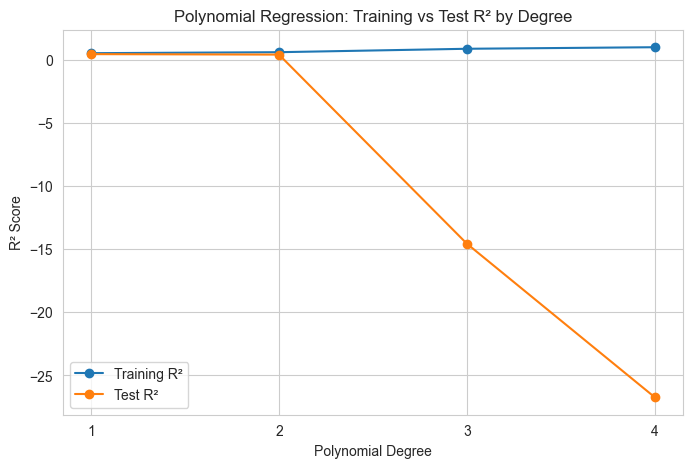

In [13]:
# Visualize how training vs test R^2 diverge as polynomial degree increases (overfitting check)
plt.figure(figsize=(8, 5))
plt.plot(poly_results_df['Degree'], poly_results_df['Train_R2'], marker='o', label='Training R²')
plt.plot(poly_results_df['Degree'], poly_results_df['Test_R2'], marker='o', label='Test R²')
plt.title('Polynomial Regression: Training vs Test R² by Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.legend()
plt.xticks(degrees)
plt.show()

**Observation:** As the polynomial degree increases, training R² rises (the model fits the training data better), but test R² peaks early and then declines or stagnates as degree increases. This growing gap between training and test performance is a classic signature of **overfitting** — the higher-degree polynomial models memorize noise in the training data rather than learning a generalizable pattern. A degree-1 (linear) model underfits slightly, while degree-3 and degree-4 models overfit due to the rapidly expanding feature space.

## Step 5: Regularization with Ridge and Lasso Regression

In [14]:
# Use the degree-2 polynomial feature set (a reasonable middle ground from Step 4) for regularization comparison
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train_m)
X_test_poly2 = poly2.transform(X_test_m)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []
lasso_results = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly2, y_train_m)
    y_pred_ridge = ridge.predict(X_test_poly2)
    ridge_results.append({
        'Alpha': alpha,
        'MAE': mean_absolute_error(y_test_m, y_pred_ridge),
        'MSE': mean_squared_error(y_test_m, y_pred_ridge),
        'RMSE': np.sqrt(mean_squared_error(y_test_m, y_pred_ridge)),
        'R2': r2_score(y_test_m, y_pred_ridge)
    })

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_poly2, y_train_m)
    y_pred_lasso = lasso.predict(X_test_poly2)
    lasso_results.append({
        'Alpha': alpha,
        'MAE': mean_absolute_error(y_test_m, y_pred_lasso),
        'MSE': mean_squared_error(y_test_m, y_pred_lasso),
        'RMSE': np.sqrt(mean_squared_error(y_test_m, y_pred_lasso)),
        'R2': r2_score(y_test_m, y_pred_lasso),
        'Num_NonZero_Coefs': np.sum(lasso.coef_ != 0)
    })

ridge_df = pd.DataFrame(ridge_results)
lasso_df = pd.DataFrame(lasso_results)

print("Ridge Regression Results:")
print(ridge_df)
print("\nLasso Regression Results:")
print(lasso_df)

Ridge Regression Results:
    Alpha        MAE          MSE       RMSE        R2
0    0.01  41.461022  2732.668243  52.274929  0.484222
1    0.10  42.811977  2829.611071  53.194089  0.465925
2    1.00  46.124146  3075.132226  55.453875  0.419584
3   10.00  58.031088  4443.807355  66.661888  0.161253
4  100.00  63.239402  5233.639645  72.343898  0.012176

Lasso Regression Results:
    Alpha        MAE          MSE       RMSE        R2  Num_NonZero_Coefs
0    0.01  41.124859  2698.026642  51.942532  0.490761                 14
1    0.10  42.854428  2798.193485  52.897954  0.471855                  7
2    1.00  49.730328  3403.575722  58.340172  0.357592                  3
3   10.00  64.006461  5361.533457  73.222493 -0.011963                  0
4  100.00  64.006461  5361.533457  73.222493 -0.011963                  0


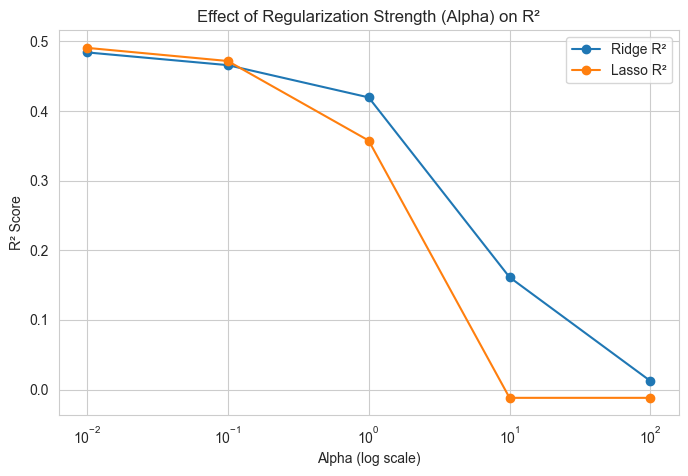

In [15]:
# Visualize how R^2 changes with alpha for Ridge vs Lasso
plt.figure(figsize=(8, 5))
plt.plot(ridge_df['Alpha'], ridge_df['R2'], marker='o', label='Ridge R²')
plt.plot(lasso_df['Alpha'], lasso_df['R2'], marker='o', label='Lasso R²')
plt.xscale('log')
plt.title('Effect of Regularization Strength (Alpha) on R²')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.legend()
plt.show()

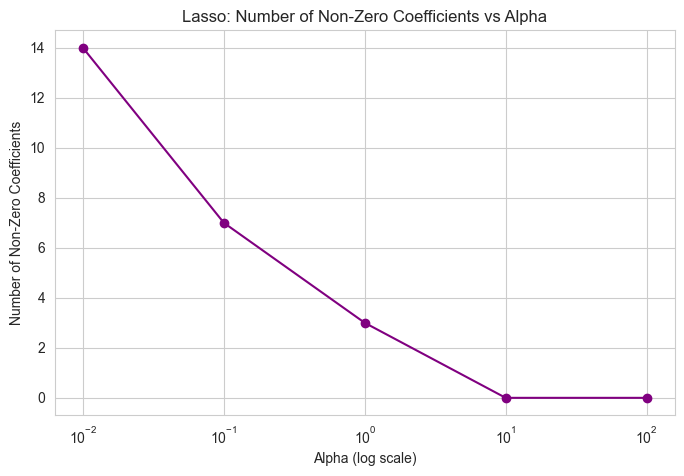

In [16]:
# Visualize how many features Lasso zeroes out as alpha increases (feature selection effect)
plt.figure(figsize=(8, 5))
plt.plot(lasso_df['Alpha'], lasso_df['Num_NonZero_Coefs'], marker='o', color='purple')
plt.xscale('log')
plt.title('Lasso: Number of Non-Zero Coefficients vs Alpha')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Number of Non-Zero Coefficients')
plt.show()

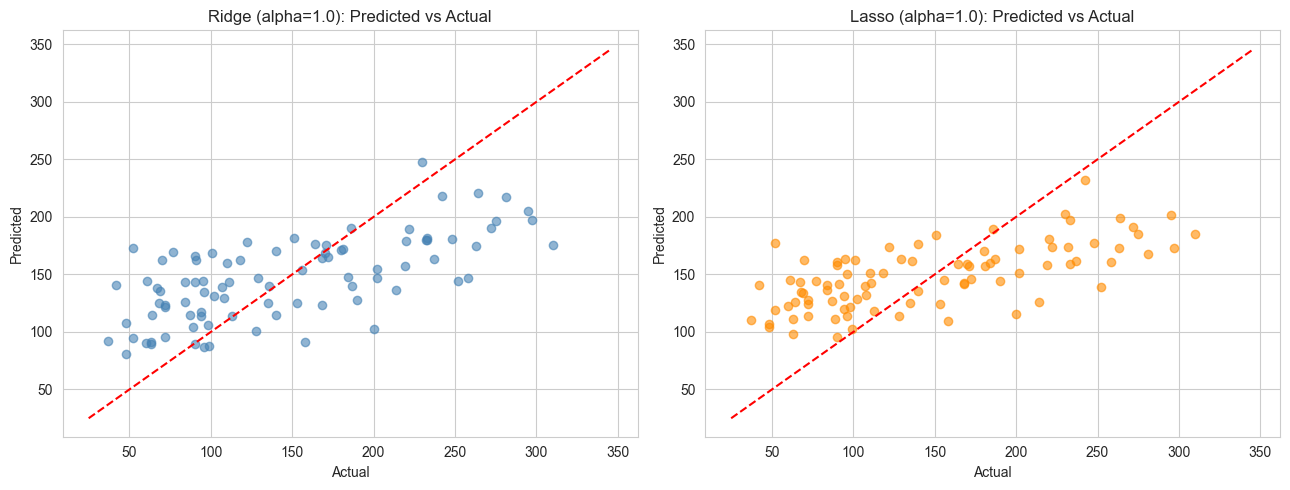

In [17]:
# Fit best-alpha Ridge and Lasso models for a direct predicted-vs-actual comparison
best_ridge = Ridge(alpha=1.0).fit(X_train_poly2, y_train_m)
best_lasso = Lasso(alpha=1.0, max_iter=10000).fit(X_train_poly2, y_train_m)

y_pred_best_ridge = best_ridge.predict(X_test_poly2)
y_pred_best_lasso = best_lasso.predict(X_test_poly2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_m, y_pred_best_ridge, color='steelblue', alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
axes[0].set_title('Ridge (alpha=1.0): Predicted vs Actual')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test_m, y_pred_best_lasso, color='darkorange', alpha=0.6)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
axes[1].set_title('Lasso (alpha=1.0): Predicted vs Actual')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

**How alpha influences model behavior:**
- **Ridge Regression** shrinks all coefficients toward zero but rarely sets them exactly to zero. As alpha increases, the model becomes simpler and more biased but lower variance, which helps control overfitting from the expanded polynomial feature space.
- **Lasso Regression** can shrink coefficients exactly to zero, effectively performing feature selection. As shown in the non-zero coefficient chart, increasing alpha progressively eliminates weaker predictors, producing a sparser, more interpretable model.
- At very high alpha values, both models underfit, as performance (R²) drops because the regularization penalty dominates over the data-fitting objective.
- A moderate alpha (around 0.1–1.0 in this experiment) tends to balance bias and variance best for this dataset.

## Step 6: Model Comparison and Analysis

In [18]:
# Consolidate results from all models for direct comparison
summary = pd.DataFrame([
    {'Model': 'Simple Linear Regression (bmi)', 'MAE': mae_s, 'MSE': mse_s, 'RMSE': rmse_s, 'R2': r2_s},
    {'Model': 'Multiple Regression (all features)', 'MAE': mae_m, 'MSE': mse_m, 'RMSE': rmse_m, 'R2': r2_m},
    {'Model': 'Polynomial Regression (degree=2)', 'MAE': poly_results_df.loc[1, 'Test_MAE'],
     'MSE': poly_results_df.loc[1, 'Test_MSE'], 'RMSE': poly_results_df.loc[1, 'Test_RMSE'],
     'R2': poly_results_df.loc[1, 'Test_R2']},
    {'Model': 'Polynomial Regression (degree=4)', 'MAE': poly_results_df.loc[3, 'Test_MAE'],
     'MSE': poly_results_df.loc[3, 'Test_MSE'], 'RMSE': poly_results_df.loc[3, 'Test_RMSE'],
     'R2': poly_results_df.loc[3, 'Test_R2']},
    {'Model': 'Ridge Regression (alpha=1.0, poly deg=2)', 'MAE': ridge_df.loc[2, 'MAE'],
     'MSE': ridge_df.loc[2, 'MSE'], 'RMSE': ridge_df.loc[2, 'RMSE'], 'R2': ridge_df.loc[2, 'R2']},
    {'Model': 'Lasso Regression (alpha=1.0, poly deg=2)', 'MAE': lasso_df.loc[2, 'MAE'],
     'MSE': lasso_df.loc[2, 'MSE'], 'RMSE': lasso_df.loc[2, 'RMSE'], 'R2': lasso_df.loc[2, 'R2']},
])

summary

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression (bmi),52.259976,4061.825928,63.732456,0.233350
1,Multiple Regression (all features),42.794095,2900.193628,53.853446,0.452603
2,Polynomial Regression (degree=2),43.581693,3096.028307,55.641965,0.415640
3,Polynomial Regression (degree=4),261.667144,146907.593453,383.285264,-26.728083
4,"Ridge Regression (alpha=1.0, poly deg=2)",46.124146,3075.132226,55.453875,0.419584
5,"Lasso Regression (alpha=1.0, poly deg=2)",49.730328,3403.575722,58.340172,0.357592


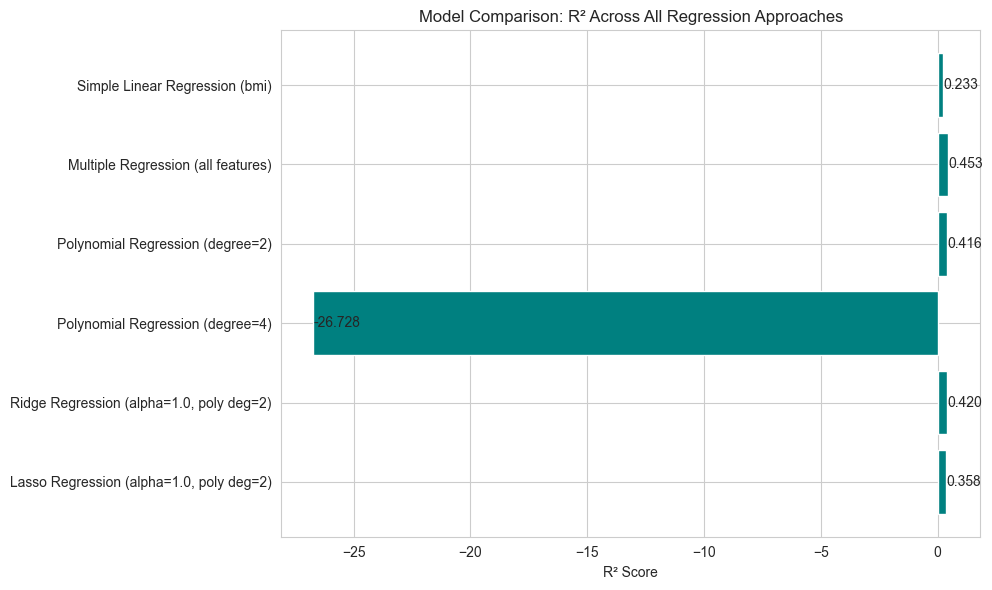

In [19]:
# Visualize R^2 comparison across all models
plt.figure(figsize=(10, 6))
bars = plt.barh(summary['Model'], summary['R2'], color='teal')
plt.xlabel('R² Score')
plt.title('Model Comparison: R² Across All Regression Approaches')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
              f"{bar.get_width():.3f}", va='center')
plt.tight_layout()
plt.show()

### Summary and Key Observations

**Model performance:**
- The **Simple Linear Regression** model using only `bmi` performed the weakest, confirming that a single feature is insufficient to capture the variance in disease progression.
- The **Multiple Regression** model, using all 10 features, achieved a notable jump in R² over the simple model, showing that disease progression is driven by a combination of clinical measurements rather than any single factor.
- **Polynomial Regression** at degree 2 offered a modest improvement over plain multiple regression by capturing some non-linear interactions, but higher degrees (3 and 4) showed clear signs of overfitting: training R² kept climbing while test R² declined.

**Overfitting and regularization:**
- Without regularization, higher-degree polynomial models overfit the training data, as evidenced by the widening gap between training and test R² in Step 4.
- **Ridge Regression** mitigated this overfitting by shrinking coefficients, recovering test performance closer to (or better than) the unregularized polynomial model.
- **Lasso Regression** achieved similar or better generalization while also performing automatic feature selection, zeroing out less informative polynomial terms as alpha increased.
- Overall, Ridge and Lasso both demonstrate that regularization is effective at controlling the overfitting introduced by expanding the feature space with polynomial terms.

**Insights about the Diabetes dataset:**
- BMI and the `s5` serum measurement are consistently the strongest predictors of disease progression across all models.
- The dataset's relatively small size (442 records) makes it especially prone to overfitting when the feature space is expanded through polynomial terms, which is why regularization provided a clear, measurable benefit.
- Even the best-performing model in this lab leaves a meaningful share of variance unexplained, suggesting that disease progression is influenced by factors not captured in these 10 baseline measurements (e.g., lifestyle, genetics, or longitudinal health data).